<a href="https://colab.research.google.com/github/ujjwalsoni3000-alt/blackhole-Schwarzschild-/blob/main/blackhole_3d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3D black hole simulation
A ray-traced Schwarzschild black hole with an accretion disk, written with NumPy only.

**How it works:** for every pixel we shoot a light ray backwards from the camera. Gravity bends the ray; we follow it until it (a) falls into the horizon (black pixel), (b) crosses the accretion disk (glowing pixel, with Doppler brightening so one side of the disk looks brighter), or (c) escapes to the starfield.

Units: G = c = M = 1 (horizon at r = 2, disk from r = 6 to 18).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import time

M = 1.0          # units: G = c = M = 1
r_s = 2 * M      # event horizon radius


## Starfield

In [ ]:
# Procedural starfield on the sky sphere (equirectangular texture)
def make_sky(h=1024, w=2048, n=7000, seed=3):
    rng = np.random.default_rng(seed)
    img = np.zeros((h, w))
    img[rng.integers(0, h, n), rng.integers(0, w, n)] = rng.random(n) ** 3 * 4
    return gaussian_filter(img, 0.9) * 8

SKY = make_sky()

def sky_lookup(t):
    """t: (N,3) unit directions -> brightness"""
    lon = np.arctan2(t[:, 1], t[:, 0])
    lat = np.arcsin(np.clip(t[:, 2], -1, 1))
    ix = ((lon / (2 * np.pi) + 0.5) * SKY.shape[1]).astype(int) % SKY.shape[1]
    iy = np.clip(((0.5 - lat / np.pi) * SKY.shape[0]).astype(int), 0, SKY.shape[0] - 1)
    return SKY[iy, ix]


## The ray tracer

In [ ]:
def norm(v):
    return v / np.maximum(np.linalg.norm(v, axis=-1, keepdims=True), 1e-12)

def render(W=480, H=270, D=60.0, elev=10.0, fov=28.0,
           r_in=6.0, r_out=16.0, alpha=0.85, dphi=0.02, max_steps=450):
    """
    Backward ray tracing in the Schwarzschild metric.
    Each light ray stays in a plane through the black hole, so we integrate
        d^2u/dphi^2 = -u + 3 M u^2      (u = 1/r)
    for every pixel at once, then convert back to 3D to test the disk (z = 0 plane).
    """
    el = np.radians(elev)
    e1 = np.array([np.cos(el), 0, np.sin(el)])        # camera direction from the BH
    f = -e1
    right = norm(np.cross(f, [0, 0, 1.0]))
    up = np.cross(right, f)

    tf = np.tan(np.radians(fov) / 2)
    X, Y = np.meshgrid(np.linspace(-1, 1, W) * tf, np.linspace(1, -1, H) * tf * H / W)
    d = norm(f + X[..., None] * right + Y[..., None] * up).reshape(-1, 3)
    N = len(d)

    dr = d @ e1
    e2 = d - dr[:, None] * e1
    dt = np.maximum(np.linalg.norm(e2, axis=1), 1e-9)
    e2 = e2 / dt[:, None]

    u = np.full(N, 1.0 / D)
    du = -u * dr / dt
    phi = np.zeros(N)

    alive = np.ones(N, bool)
    captured = np.zeros(N, bool)
    T = np.ones(N)                    # transmittance
    rgb = np.zeros((N, 3))
    esc_dir = np.zeros((N, 3))
    cmap = plt.cm.inferno

    acc = lambda x: -x + 3 * M * x * x
    pos = lambda ph, uu, E2: (np.cos(ph)[:, None] * e1 + np.sin(ph)[:, None] * E2) / uu[:, None]

    h = dphi
    for _ in range(max_steps):
        idx = np.flatnonzero(alive)
        if idx.size == 0:
            break
        uu, dd, ph, E2 = u[idx], du[idx], phi[idx], e2[idx]

        # RK4 step
        k1u, k1d = dd, acc(uu)
        k2u, k2d = dd + .5*h*k1d, acc(uu + .5*h*k1u)
        k3u, k3d = dd + .5*h*k2d, acc(uu + .5*h*k2u)
        k4u, k4d = dd + h*k3d,   acc(uu + h*k3u)
        un = uu + h/6 * (k1u + 2*k2u + 2*k3u + k4u)
        dn = dd + h/6 * (k1d + 2*k2d + 2*k3d + k4d)
        phn = ph + h

        p0, p1 = pos(ph, uu, E2), pos(phn, un, E2)

        # --- accretion disk crossing (z = 0 plane) ---
        cross = p0[:, 2] * p1[:, 2] < 0
        if cross.any():
            c = np.flatnonzero(cross)
            w = p0[c, 2] / (p0[c, 2] - p1[c, 2])
            ph_hit = p0[c] + w[:, None] * (p1[c] - p0[c])
            r_hit = np.linalg.norm(ph_hit, axis=1)
            ok = (r_hit > r_in) & (r_hit < r_out)
            if ok.any():
                c, ph_hit, r_hit = c[ok], ph_hit[ok], r_hit[ok]
                t = norm(p1[c] - p0[c])                       # ray direction (away from camera)
                vel = np.stack([-ph_hit[:, 1], ph_hit[:, 0], np.zeros(len(c))], 1)
                vel = vel / r_hit[:, None] * np.sqrt(M / r_hit)[:, None]   # Keplerian velocity
                v2 = (vel ** 2).sum(1)
                g = np.sqrt(1 - v2) / (1 + (vel * t).sum(1))               # Doppler factor
                temp = (r_in / r_hit) ** 0.75 * g
                inten = (r_in / r_hit) ** 1.5 * g ** 3
                col = cmap(np.clip(temp * 0.85, 0, 1))[:, :3]
                gi = idx[c]
                rgb[gi] += (T[gi] * alpha * inten)[:, None] * col
                T[gi] *= (1 - alpha)

        # --- fate of rays ---
        cap = un >= 1.0 / r_s
        esc = (dn < 0) & (un < 0.5 / D)
        captured[idx[cap]] = True
        if esc.any():
            esc_dir[idx[esc]] = norm(p1[esc] - p0[esc])
        alive[idx[cap | esc]] = False

        u[idx], du[idx], phi[idx] = un, dn, phn

    escaped = (~alive) & (~captured)
    bg = np.zeros(N)
    bg[escaped] = sky_lookup(esc_dir[escaped])
    rgb += (T * bg)[:, None] * np.array([0.8, 0.85, 1.0])

    img = rgb.reshape(H, W, 3)
    img = img / np.percentile(img, 99.7)
    return np.clip(img, 0, 1) ** (1 / 1.8)


## Render (takes ~10–40 s)
You'll see the black shadow, the bright thin disk, and the disk's far side bent over the top and under the bottom of the hole.

rendered in 6.5s


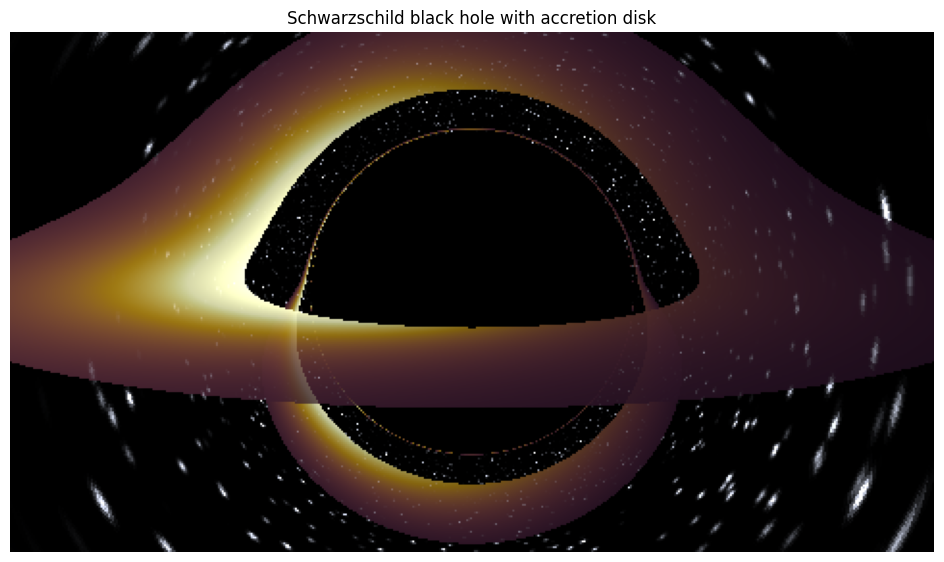

In [ ]:
t0 = time.time()
img = render(W=480, H=270, elev=10)
print(f"rendered in {time.time()-t0:.1f}s")

plt.figure(figsize=(12, 6.75))
plt.imshow(img); plt.axis("off")
plt.title("Schwarzschild black hole with accretion disk")
plt.show()

## Other viewing angles

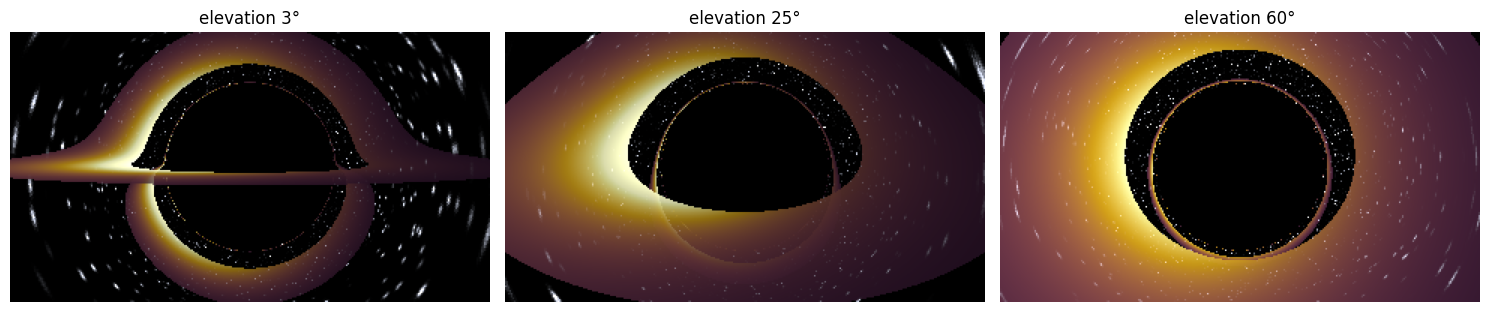

In [ ]:
# Try different viewing angles (elev = degrees above the disk plane)
fig, axs = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, el in zip(axs, [3, 25, 60]):
    ax.imshow(render(W=320, H=180, elev=el)); ax.set_title(f"elevation {el}°"); ax.axis("off")
plt.tight_layout(); plt.show()

## 3D orbit plot

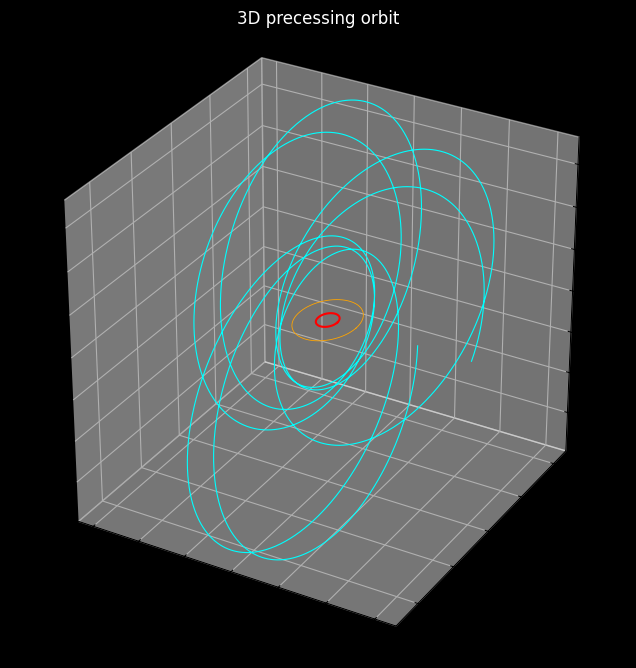

In [ ]:
# 3D orbit of a particle around the black hole (plane tilted 40 degrees)
from scipy.integrate import solve_ivp
L = 4.2
f = lambda p, y: [y[1], M / L**2 - y[0] + 3 * M * y[0] ** 2]
hit = lambda p, y: y[0] - 1 / r_s
hit.terminal = True
sol = solve_ivp(f, [0, 14 * np.pi], [1 / 30, 0], events=hit, max_step=0.01, rtol=1e-9)
ph, uu = sol.t, sol.y[0]
tilt = np.radians(40)
x = np.cos(ph) / uu
yy = np.sin(ph) / uu
X, Y, Z = x, yy * np.cos(tilt), yy * np.sin(tilt)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection="3d")
ax.plot(X, Y, Z, color="cyan", lw=0.8)
a = np.linspace(0, 2*np.pi, 200)
ax.plot(r_s*np.cos(a), r_s*np.sin(a), 0*a, color="red")           # horizon (equator)
ax.plot(6*np.cos(a), 6*np.sin(a), 0*a, color="orange", lw=0.6)    # ISCO
ax.set_facecolor("black"); fig.patch.set_facecolor("black")
ax.set_box_aspect((1, 1, 1)); ax.set_title("3D precessing orbit", color="white")
plt.show()
# tip: run  %matplotlib widget  (needs ipympl) above this cell to rotate it with the mouse

## Things to tweak
- `elev`: camera angle, `D`: camera distance, `fov`: zoom
- `r_in`, `r_out`, `alpha`: disk size and opacity
- `W`, `H`: resolution (bigger = slower)
- Next steps: spinning (Kerr) black hole, a movie by looping `elev`, or porting to GPU with CuPy